In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


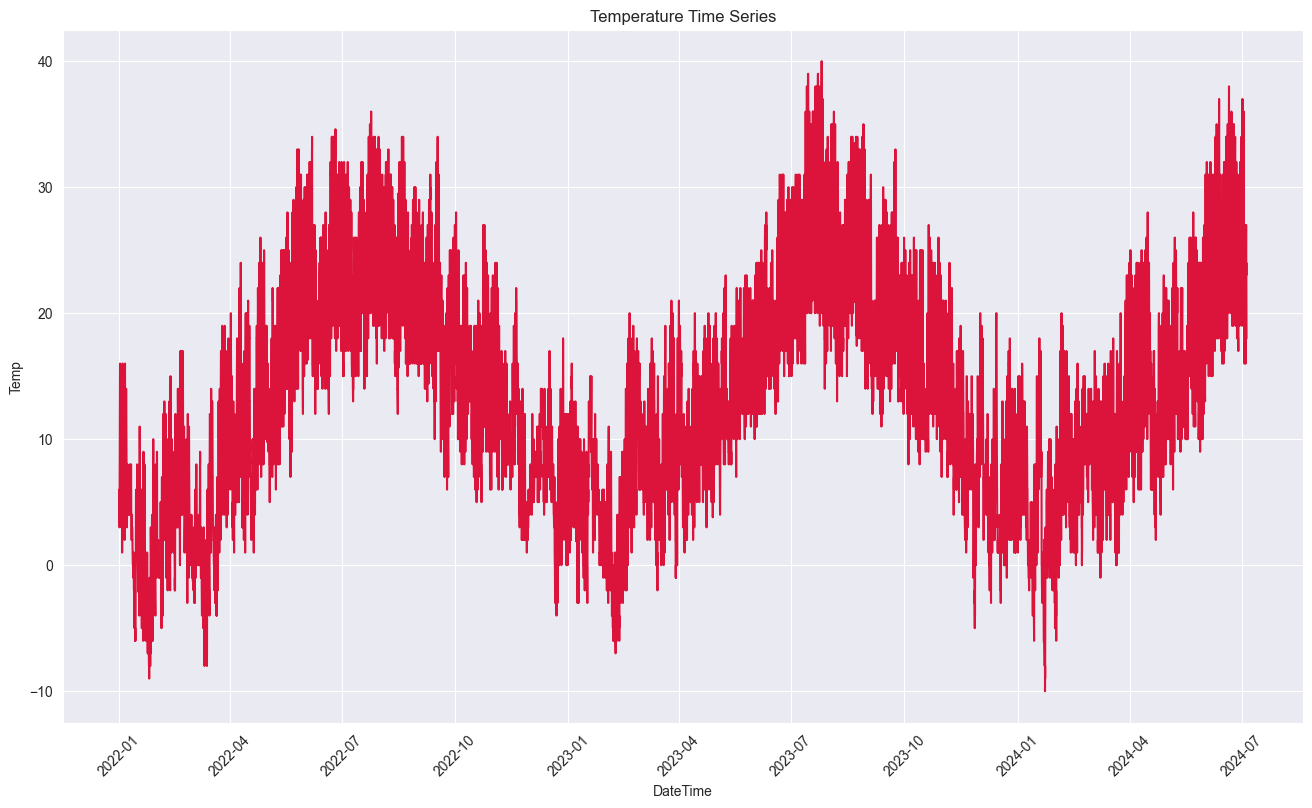

In [3]:
sns.set_style("darkgrid")
plt.figure(figsize= (16, 9))
sns.lineplot(x = data.index, y = "temp", data= data, color = "Crimson")
plt.title("Temperature Time Series")
plt.xlabel("DateTime")
plt.ylabel("Temp")
plt.xticks(rotation = 45)
plt.show()

In [3]:
df_picked = data[["temp", "humidity", "winddir", "solarradiation", "cloudcover", "Kwh"]]
print(df_picked.head(), "\n", df_picked.info(), "\n", df_picked.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21983 entries, 2022-01-01 00:00:00 to 2024-07-04 23:00:00
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp            21983 non-null  float64
 1   humidity        21983 non-null  float64
 2   winddir         21983 non-null  float64
 3   solarradiation  21982 non-null  float64
 4   cloudcover      21983 non-null  float64
 5   Kwh             21983 non-null  float64
dtypes: float64(6)
memory usage: 1.2 MB
                     temp  humidity  winddir  solarradiation  cloudcover  Kwh
datetime                                                                     
2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0  0.0
2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0  0.0
2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9  0.0
2022-01-01 03:00:00   4.0     80.80    294.8             0.0       

In [4]:
df_picked.isna().sum()

temp              0
humidity          0
winddir           0
solarradiation    1
cloudcover        0
Kwh               0
dtype: int64

In [5]:
df_picked[df_picked["solarradiation"].isna()], df_picked.iloc[-1]

(                     temp  humidity  winddir  solarradiation  cloudcover  \
 datetime                                                                   
 2024-07-01 13:00:00  33.9     24.14    126.3             NaN         0.0   
 
                         Kwh  
 datetime                     
 2024-07-01 13:00:00  0.6906  ,
 temp              18.00
 humidity          63.61
 winddir            0.00
 solarradiation     0.00
 cloudcover        68.30
 Kwh                0.00
 Name: 2024-07-04 23:00:00, dtype: float64)

In [6]:
df_picked = df_picked.dropna()
df_picked.shape

(21982, 6)

In [7]:
df_picked.describe()

,temp,humidity,winddir,solarradiation,cloudcover,Kwh
count,21982.000000,21982.000000,21982.000000,21982.000000,21982.000000,21982.000000
mean,13.413816,60.207503,217.831821,176.518961,47.740197,0.151421
std,8.778834,22.578112,136.031074,264.418006,38.836746,0.222730
min,-10.000000,8.300000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,42.300000,90.000000,0.000000,4.800000,0.000000
50%,13.000000,59.280000,290.000000,11.000000,49.100000,0.001200
75%,20.000000,77.910000,340.000000,298.000000,88.300000,0.278400
max,40.000000,100.000000,360.000000,1157.000000,100.000000,0.809800


# LSTM Preprocess

In [8]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :5]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [9]:
x, y = df_to_x_y(df_picked, size= 24)
x.shape, y.shape

((21958, 24, 5), (21958,))

In [10]:
x, y

(array([[[  6.  ,  75.51, 240.  ,   0.  ,   0.  ],
         [  6.  ,  75.51, 298.1 ,   0.  ,   0.  ],
         [  4.9 ,  81.61, 301.  ,   0.  ,  40.9 ],
         ...,
         [  9.  ,  57.27, 330.  ,   0.  ,   0.  ],
         [  6.  ,  70.29,  30.  ,   0.  ,   0.7 ],
         [  9.  ,  53.31, 320.  ,   0.  ,   0.7 ]],
 
        [[  6.  ,  75.51, 298.1 ,   0.  ,   0.  ],
         [  4.9 ,  81.61, 301.  ,   0.  ,  40.9 ],
         [  4.  ,  80.8 , 294.8 ,   0.  ,  38.  ],
         ...,
         [  6.  ,  70.29,  30.  ,   0.  ,   0.7 ],
         [  9.  ,  53.31, 320.  ,   0.  ,   0.7 ],
         [  8.  ,  61.29, 340.  ,   0.  ,   8.5 ]],
 
        [[  4.9 ,  81.61, 301.  ,   0.  ,  40.9 ],
         [  4.  ,  80.8 , 294.8 ,   0.  ,  38.  ],
         [  3.  ,  93.14, 292.3 ,   0.  ,  41.7 ],
         ...,
         [  9.  ,  53.31, 320.  ,   0.  ,   0.7 ],
         [  8.  ,  61.29, 340.  ,   0.  ,   8.5 ],
         [  9.  ,  53.28, 360.  ,   0.  ,   0.  ]],
 
        ...,
 
        [[ 24.  

In [11]:
x_train , y_train = x[:int(0.8*len(x))], y[: int(0.8*len(y))]
x_val, y_val = x[int(0.8*len(x)): int(0.9*len(x))], y[int(0.8*len(y)): int(0.9*len(y))]
x_test, y_test = x[int(0.9*len(x)):], y[int(0.9*len(y)):]

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((17566, 24, 5), (17566,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [12]:
model_1 = Sequential()
model_1.add(LSTM(64, input_shape = (24, 5)))
model_1.add(Dense(8, "relu"))
model_1.add(Dense(1, "linear"))

model_1.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,449 (72.07 KB)

 Trainable params: 18,449 (72.07 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_1.compile(loss= MeanSquaredError(), optimizer= Adam(learning_rate= 1e-4), metrics= [RootMeanSquaredError()])

In [14]:
def visualize_loss(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    #plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    #plt.savefig('../plots/history_{}.png'.format(fold))
    plt.show()

In [13]:
model_fit_1 = model_1.fit(x_train, y_train, 
            validation_data = (x_val, y_val), 
            epochs = 20,
            batch_size=32
            )

Epoch 1/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0975 - root_mean_squared_error: 0.3085 - val_loss: 0.0333 - val_root_mean_squared_error: 0.1827
Epoch 2/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0292 - root_mean_squared_error: 0.1708 - val_loss: 0.0217 - val_root_mean_squared_error: 0.1476
Epoch 3/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0212 - root_mean_squared_error: 0.1457 - val_loss: 0.0173 - val_root_mean_squared_error: 0.1317
Epoch 4/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0170 - root_mean_squared_error: 0.1303 - val_loss: 0.0149 - val_root_mean_squared_error: 0.1222
Epoch 5/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0157 - root_mean_squared_error: 0.1253 - val_loss: 0.0136 - val_root_mean_squared_error: 0.1167
Epoch 6/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0138 - root_mean_squared_error: 0.1176 - val_loss: 0.0129 - val_root_mean_squared_error: 0.1136
Epoch 7/20
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step 

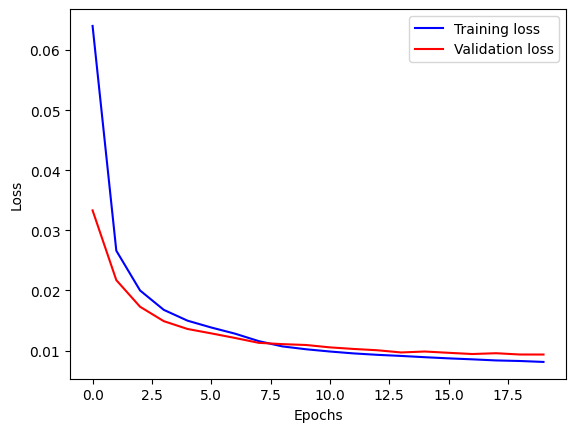

In [14]:
visualize_loss(model_fit_1)

In [92]:
val_predictions = model_1.predict(x_val).flatten()
val_results = pd.DataFrame({"Val Predictions" : val_predictions, "Real Data" : y_val})
val_results

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Val Predictions,Real Data
0,0.012212,0.0000
1,-0.007964,0.0000
2,-0.013972,0.0000
3,0.012889,0.0000
4,0.009907,0.0000
...,...,...
2191,0.048575,0.0000
2192,0.049653,0.0210
2193,0.085647,0.2181
2194,0.391105,0.4026


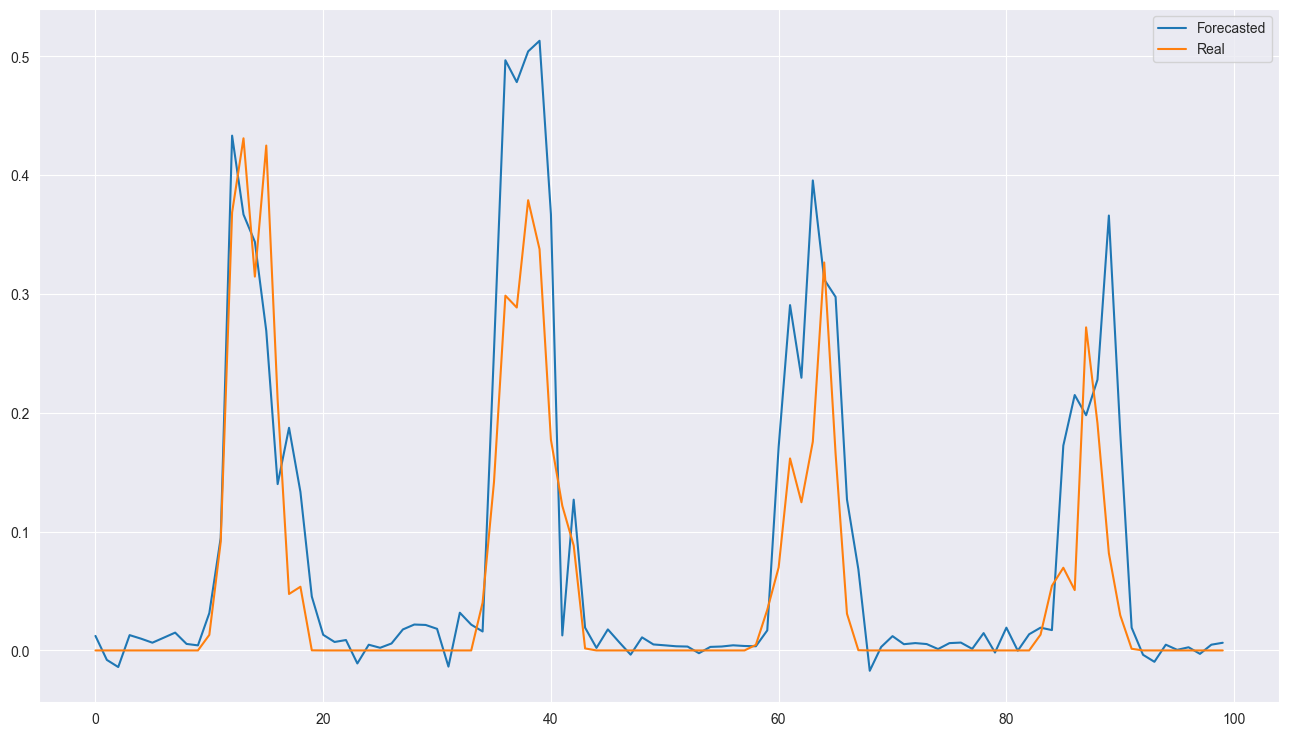

In [99]:
plt.figure(figsize= (16, 9))
plt.plot(val_results["Val Predictions"][:100], label = "Forecasted")
plt.plot(val_results["Real Data"][:100], label = "Real")
plt.legend()
plt.show()

In [16]:
test_predictions = model_1.predict(x_test).flatten()
test_results = pd.DataFrame({"Val Predictions" : test_predictions, "Real Data" : y_test})
test_results

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Val Predictions,Real Data
0,0.597127,0.6587
1,0.726446,0.7136
2,0.636293,0.7147
3,0.502072,0.6763
4,0.460225,0.5901
...,...,...
2191,0.152165,0.0592
2192,0.043762,0.0085
2193,0.038593,0.0000
2194,0.007250,0.0000


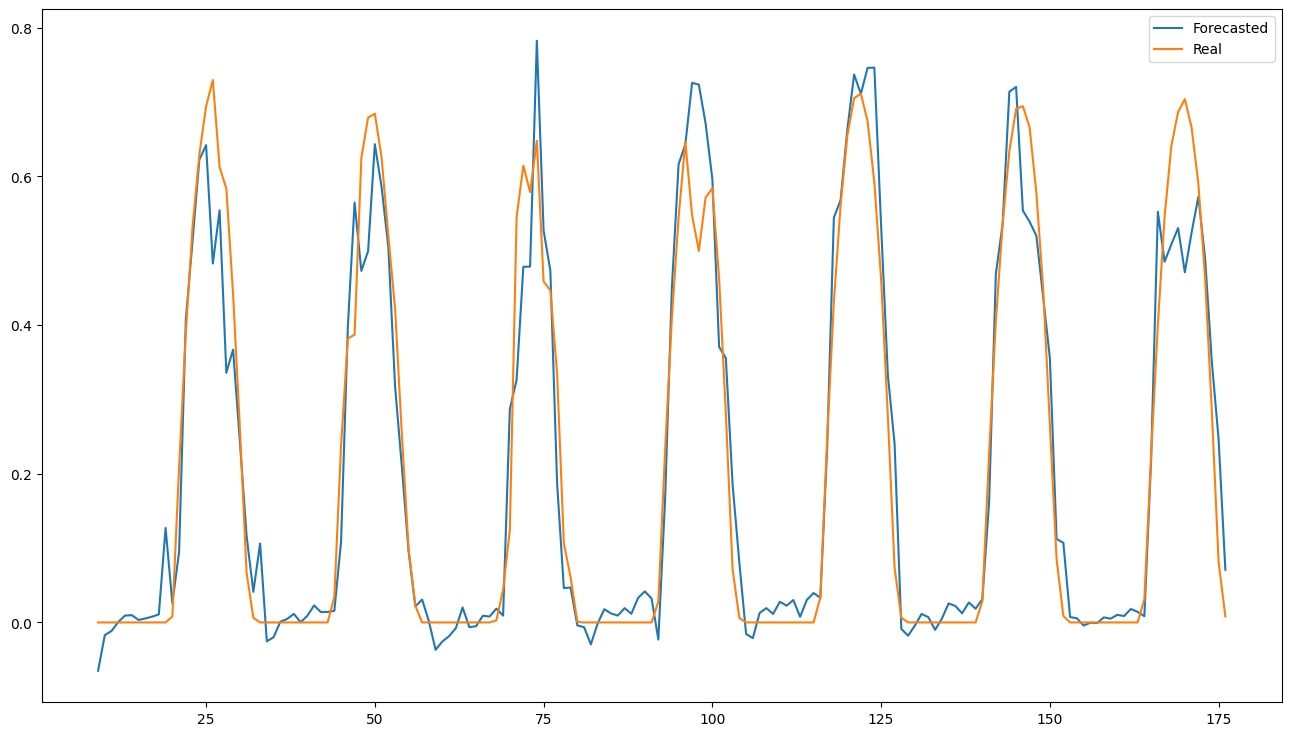

In [17]:
plt.figure(figsize= (16, 9))
plt.plot(test_results["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

In [97]:
test_results.head(20)

,Val Predictions,Real Data
0,0.586846,0.6587
1,0.582452,0.7136
2,0.607516,0.7147
3,0.591219,0.6763
4,0.583356,0.5901
5,0.510402,0.4559
6,0.418663,0.2704
7,0.120158,0.0625
8,0.055011,0.0057
9,0.019175,0.0000


# Standardization

In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [15]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_picked.iloc[:, :5])
df_scaled = pd.DataFrame(df_scaled)
df_scaled.tail(20)

,0,1,2,3,4
21962,0.294600,0.750412,0.824596,-0.667591,1.345658
21963,0.294600,0.531611,0.677568,-0.667591,1.345658
21964,0.408513,0.334513,0.898111,-0.667591,1.036666
21965,0.408513,0.140958,0.971625,-0.380160,1.036666
21966,0.408513,-0.041524,0.898111,-0.175934,1.036666
21967,0.522426,-0.202302,0.971625,0.357325,1.036666
21968,0.750252,-0.633704,0.971625,0.656101,1.036666
21969,0.978077,-0.868892,0.898111,2.255877,1.036666
21970,1.319816,-1.265303,0.971625,0.822508,-0.585546
21971,1.319816,-1.166533,0.751082,0.323287,-0.585546


In [16]:
df_sacled_reset = df_scaled.reset_index(drop=True)
df_picked_reset = df_picked.reset_index(drop=True)

# Concatenate the DataFrames
df_sacled = pd.concat([df_sacled_reset, df_picked_reset["Kwh"]], axis=1)


In [17]:
df_sacled

,0,1,2,3,4,Kwh
0,-0.844529,0.677773,0.162968,-0.667591,-1.229281,0.0000
1,-0.844529,0.677773,0.590086,-0.667591,-1.229281,0.0000
2,-0.969834,0.947953,0.611405,-0.667591,-0.176131,0.0000
3,-1.072355,0.912076,0.565826,-0.667591,-0.250804,0.0000
4,-1.186268,1.458636,0.547448,-0.667591,-0.155531,0.0000
...,...,...,...,...,...,...
21977,1.205903,-0.844089,-0.278118,0.115279,0.812646,0.0592
21978,1.091990,-0.856491,-0.331048,-0.278047,0.874444,0.0085
21979,0.864164,-0.479126,-1.601375,-0.633553,0.410955,0.0000
21980,0.750252,-0.179714,-1.601375,-0.667591,0.457304,0.0000


In [18]:
x_2, y_2 = df_to_x_y(df_sacled, size= 24)
x_2.shape, y_2.shape

((21958, 24, 5), (21958,))

In [19]:
x_train_2 , y_train_2 = x_2[:int(0.8*len(x))], y_2[: int(0.8*len(y))]
x_val_2, y_val_2 = x_2[int(0.8*len(x)): int(0.9*len(x))], y_2[int(0.8*len(y)): int(0.9*len(y))]
x_test_2, y_test_2 = x_2[int(0.9*len(x)):], y_2[int(0.9*len(y)):]

x_train_2.shape, y_train_2.shape, x_val_2.shape, y_val_2.shape, x_test_2.shape, y_test_2.shape

((17566, 24, 5), (17566,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [20]:
checkpoint = ModelCheckpoint(
    '/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras', 
    monitor='val_loss', 
    save_best_only=True,
    mode='min',
    verbose=1
)


In [23]:
model_1.fit(x_train_2, y_train_2, 
            validation_data = (x_val_2, y_val_2), 
            epochs = 50,
            batch_size=32,
            callbacks = [checkpoint]
            )

Epoch 1/50
542/549 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0315 - root_mean_squared_error: 0.1756
Epoch 1: val_loss improved from inf to 0.01163, saving model to /Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0313 - root_mean_squared_error: 0.1751 - val_loss: 0.0116 - val_root_mean_squared_error: 0.1078
Epoch 2/50
538/549 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - root_mean_squared_error: 0.1002
Epoch 2: val_loss improved from 0.01163 to 0.00836, saving model to /Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0100 - root_mean_squared_error: 0.1001 - val_loss: 0.0084 - val_root_mean_squared_error: 0.0915
Epoch 3/50
537/549 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - root_mean_squared_error: 0.0861
Epoch 3: val_loss improved from 0.00836 to 0.00695, saving model to /Users/irakli

In [24]:
val_predictions_2 = model_1.predict(x_val_2).flatten()
val_results_2 = pd.DataFrame({"Val Predictions" : val_predictions_2, "Real Data" : y_val_2})
val_results_2

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Val Predictions,Real Data
0,0.006315,0.0000
1,0.002031,0.0000
2,0.007974,0.0000
3,0.007288,0.0000
4,0.007734,0.0000
...,...,...
2191,0.043878,0.0000
2192,0.171651,0.0210
2193,0.328148,0.2181
2194,0.510185,0.4026


In [25]:
test_predictions_2 = model_1.predict(x_test_2).flatten()
test_results_2 = pd.DataFrame({"Val Predictions" : test_predictions_2, "Real Data" : y_test_2})
test_results_2

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Val Predictions,Real Data
0,0.766106,0.6587
1,0.757366,0.7136
2,0.712446,0.7147
3,0.657547,0.6763
4,0.558451,0.5901
...,...,...
2191,0.071016,0.0592
2192,0.019018,0.0085
2193,0.009184,0.0000
2194,0.002442,0.0000


In [26]:
test_results_2.index = df_picked.iloc[-2196:].index

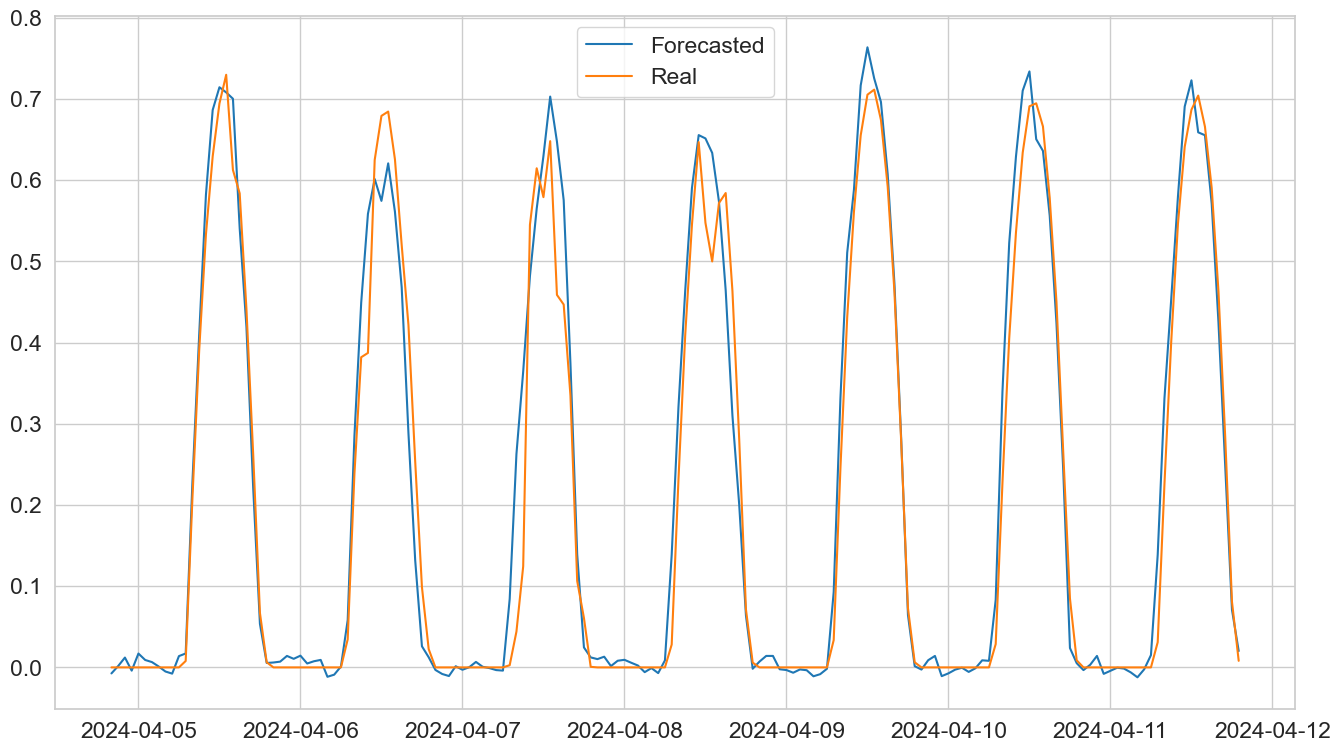

In [27]:
plt.figure(figsize= (16, 9))
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(test_results_2["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_2["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

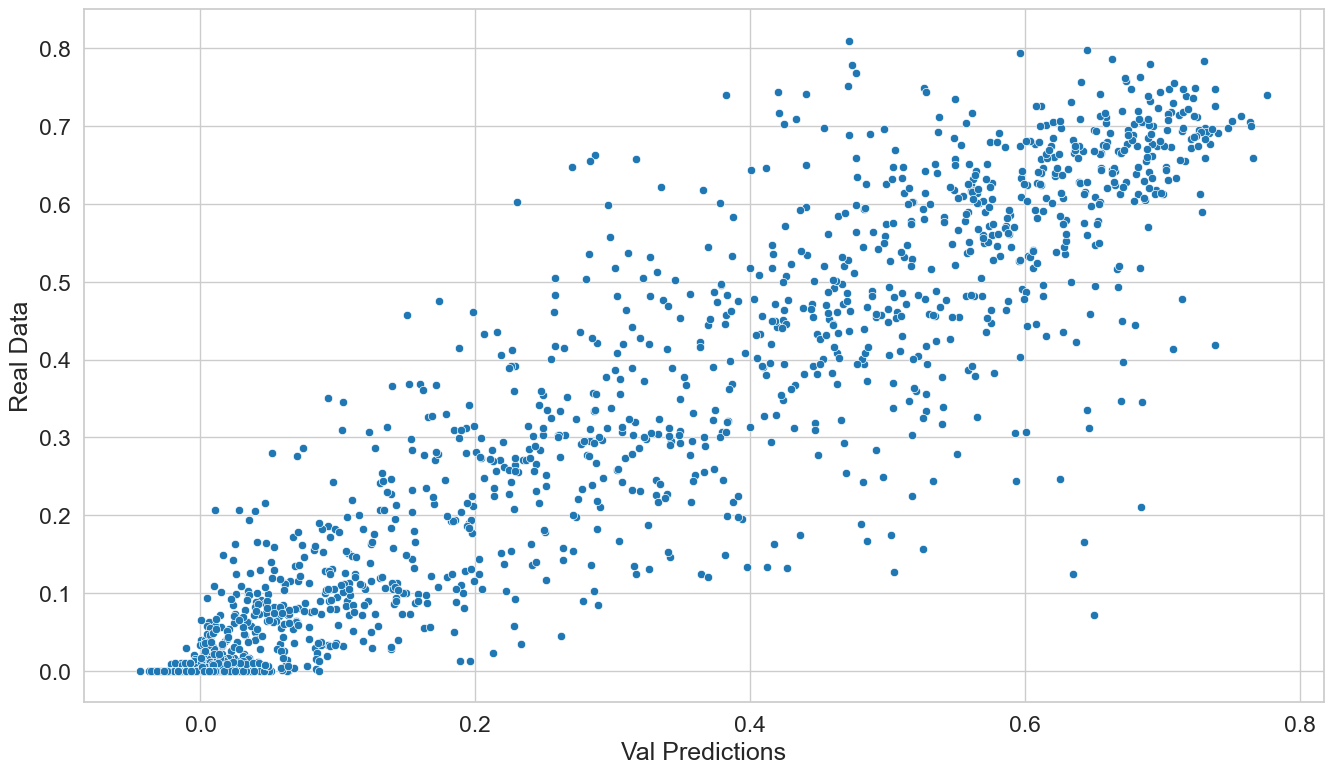

In [28]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Val Predictions", y = "Real Data", data = test_results_2)
plt.show()

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(test_results_2["Real Data"], test_results_2["Val Predictions"])
tss = ((test_results_2["Real Data"] - test_results_2["Real Data"].mean()) ** 2).sum()
res = np.sum((test_results_2["Real Data"] - test_results_2["Val Predictions"])**2)
r2 = 1 - (res / tss)
mse, r2

(0.006705478824174327, 0.8919257739633207)

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(test_results_2["Real Data"], test_results_2["Val Predictions"])
print(f"R^2: {r2}")


R^2: 0.8926182797685789


# Normalization

In [30]:
m_M_scaler = MinMaxScaler()
df_norm = m_M_scaler.fit_transform(df_picked.iloc[:, :5])
df_norm = pd.DataFrame(df_norm)
df_norm.tail(20)

,0,1,2,3,4
21962,0.52,0.750818,0.916667,0.000000,1.000
21963,0.52,0.696947,0.861111,0.000000,1.000
21964,0.54,0.648419,0.944444,0.000000,0.880
21965,0.54,0.600763,0.972222,0.065687,0.880
21966,0.54,0.555834,0.944444,0.112360,0.880
21967,0.56,0.516249,0.972222,0.234226,0.880
21968,0.60,0.410033,0.972222,0.302506,0.880
21969,0.64,0.352126,0.944444,0.668107,0.880
21970,0.70,0.254526,0.972222,0.340536,0.250
21971,0.70,0.278844,0.888889,0.226448,0.250


In [36]:
df_norm_reset = df_norm.reset_index(drop=True)
df_picked_reset = df_picked.reset_index(drop=True)

# Concatenate the DataFrames
df_norm = pd.concat([df_norm_reset, df_picked_reset["Kwh"]], axis=1)
df_norm

,0,1,2,3,4,Kwh
0,0.320,0.732933,0.666667,0.000000,0.000,0.0000
1,0.320,0.732933,0.828056,0.000000,0.000,0.0000
2,0.298,0.799455,0.836111,0.000000,0.409,0.0000
3,0.280,0.790622,0.818889,0.000000,0.380,0.0000
4,0.260,0.925191,0.811944,0.000000,0.417,0.0000
...,...,...,...,...,...,...
21977,0.680,0.358233,0.500000,0.178911,0.793,0.0592
21978,0.660,0.355180,0.480000,0.089023,0.817,0.0085
21979,0.620,0.448092,0.000000,0.007779,0.637,0.0000
21980,0.600,0.521810,0.000000,0.000000,0.655,0.0000


In [37]:
x_3, y_3 = df_to_x_y(df_norm, size= 24)
x_3.shape, y_3.shape

((21958, 24, 5), (21958,))

In [38]:
x_train_3 , y_train_3 = x_3[:int(0.8*len(x))], y_3[: int(0.8*len(y))]
x_val_3, y_val_3 = x_3[int(0.8*len(x)): int(0.9*len(x))], y_3[int(0.8*len(y)): int(0.9*len(y))]
x_test_3, y_test_3 = x_3[int(0.9*len(x)):], y_3[int(0.9*len(y)):]

x_train_3.shape, y_train_3.shape, x_val_3.shape, y_val_3.shape, x_test_3.shape, y_test_3.shape

((17566, 24, 5), (17566,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [45]:
model_1.fit(x_train_3, y_train_3, 
            validation_data = (x_val_3, y_val_3), 
            epochs = 50,
            batch_size=32,
            callbacks = [checkpoint]
            )

Epoch 1/50
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040 - root_mean_squared_error: 0.0634
Epoch 1: val_loss did not improve from 0.00427
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0040 - root_mean_squared_error: 0.0634 - val_loss: 0.0052 - val_root_mean_squared_error: 0.0720
Epoch 2/50
536/549 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042 - root_mean_squared_error: 0.0646
Epoch 2: val_loss did not improve from 0.00427
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0042 - root_mean_squared_error: 0.0646 - val_loss: 0.0049 - val_root_mean_squared_error: 0.0699
Epoch 3/50
545/549 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - root_mean_squared_error: 0.0638
Epoch 3: val_loss did not improve from 0.00427
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0041 - root_mean_squared_error: 0.0638 - val_loss: 0.0045 - val_root_mean_squared_error: 0.0670
Epoch 4/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - root_mean_squared_error: 0.0643
Epoch 4: val_l

In [42]:
test_predictions_3 = model_1.predict(x_test_3).flatten()
test_results_3 = pd.DataFrame({"Val Predictions" : test_predictions_3, "Real Data" : y_test_3})

test_results_3.index = df_picked.iloc[-2196:].index

test_results_3


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Val Predictions,Real Data
datetime,,
2024-04-04 11:00:00,0.749064,0.6587
2024-04-04 12:00:00,0.760446,0.7136
2024-04-04 13:00:00,0.736268,0.7147
2024-04-04 14:00:00,0.667484,0.6763
2024-04-04 15:00:00,0.573099,0.5901
...,...,...
2024-07-04 19:00:00,0.093019,0.0592
2024-07-04 20:00:00,0.031923,0.0085
2024-07-04 21:00:00,0.014013,0.0000


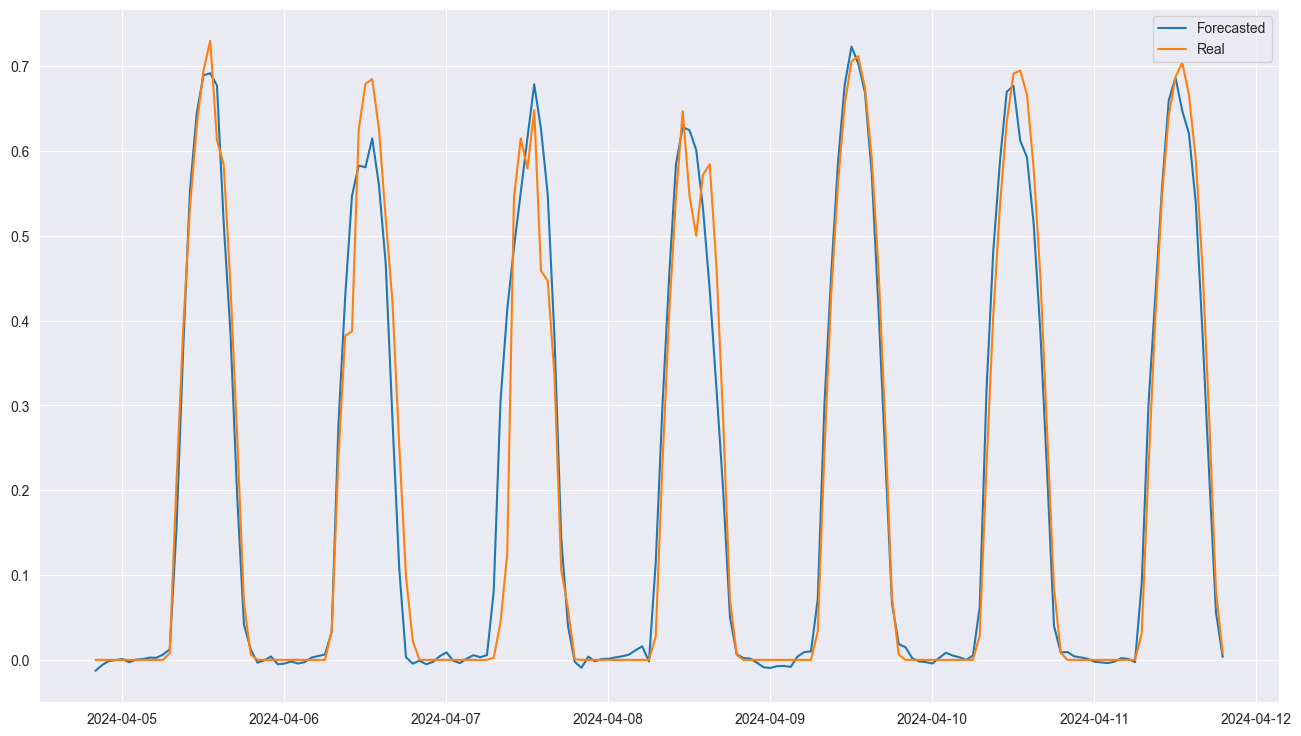

In [ ]:
plt.figure(figsize= (16, 9))
sns.set_context("notebook", font_scale=1.5)
sns.set_style("whitegrid")
plt.plot(test_results_2["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results_2["Real Data"][9:177], label = "Real")
plt.xticks(rotation = 45)
plt.legend(loc = "upper right")
plt.show()

In [44]:
r_squared= r2_score(test_results_3["Real Data"], test_results_3["Val Predictions"])
print(f"R^2: {r_squared}")


R^2: 0.8825611426328095
